In [2]:
!which python

/home/shreya/venvs/jupyter/bin/python


In [3]:
# Debug: inspect dataset slice contents before tokenization
from datasets import load_dataset
valid_sample = load_dataset("glue", "sst2", split="validation[:8]")
print(type(valid_sample))
print(valid_sample.column_names)
print(type(valid_sample["sentence"]))
print(valid_sample["sentence"][:3])
print("len sentences:", len(valid_sample["sentence"]))
print("example type:", type(valid_sample["sentence"][0]))


<class 'datasets.arrow_dataset.Dataset'>
['sentence', 'label', 'idx']
<class 'datasets.arrow_dataset.Column'>
["it 's a charming and often affecting journey . ", 'unflinchingly bleak and desperate ', 'allows us to hope that nolan is poised to embark a major career as a commercial yet inventive filmmaker . ']
len sentences: 8
example type: <class 'str'>


In [ ]:
# Setup: load model, apply QAT, and prepare profiling inputs
import os
import sys
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, DistilBertConfig, DistilBertForSequenceClassification
from torchao.quantization.qat.linear import Int8DynActInt4WeightQATLinear

# Ensure repo root is on sys.path so src imports work from notebook directories.
root_candidate = os.path.abspath(os.path.join(os.getcwd(), ".."))
if os.path.exists(os.path.join(root_candidate, "src")):
    sys.path.insert(0, root_candidate)
elif os.path.exists(os.path.join(os.getcwd(), "src")):
    sys.path.insert(0, os.getcwd())
else:
    raise RuntimeError("Could not locate repository root containing src/ from notebook working directory.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Load a small validation sample for profiling and stability analysis
valid_sample = load_dataset("glue", "sst2", split="validation[:8]")
sentences = [str(x) for x in valid_sample["sentence"]]
enc = tokenizer(
    sentences,
    padding="max_length",
    truncation=True,
    max_length=64,
    return_tensors="pt",
)
profiling_inputs = {
    "input_ids": enc["input_ids"].to(DEVICE),
    "attention_mask": enc["attention_mask"].to(DEVICE),
}

# Save outputs to results/ under the repo root
SAVE_DIR = os.path.abspath(os.path.join(root_candidate, "results"))
os.makedirs(os.path.join(SAVE_DIR, "checkpoints"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "profiles"), exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, "figures"), exist_ok=True)

# Build and restore the QAT model
config = DistilBertConfig()
config.num_labels = 2
base_model = DistilBertForSequenceClassification(config).to(DEVICE)
ckpt_path = "results/checkpoints/qat_finetuned.pt"
if not os.path.exists(ckpt_path):
    candidate = os.path.abspath(os.path.join("..", ckpt_path))
    if os.path.exists(candidate):
        ckpt_path = candidate
    else:
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path} or {candidate}")
ckpt = torch.load(ckpt_path, map_location=DEVICE)
base_model.load_state_dict(ckpt, strict=True)


def apply_qat_to_linear(model):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            qat_linear = Int8DynActInt4WeightQATLinear(
                module.in_features,
                module.out_features,
                bias=False,
                groupsize=32,
            ).to(DEVICE)
            with torch.no_grad():
                qat_linear.weight.copy_(module.weight)
                if module.bias is not None:
                    qat_linear.bias = torch.nn.Parameter(module.bias.clone().to(DEVICE))
            setattr(model, name, qat_linear)
        else:
            apply_qat_to_linear(module)
    return model

qat_model = apply_qat_to_linear(base_model)
qat_model.eval()

# Optional FP32 baseline for later comparisons
fp32_model = DistilBertForSequenceClassification(config).to(DEVICE)
fp32_model.load_state_dict(ckpt, strict=True)
fp32_model.eval()
print("Setup complete: qat_model, fp32_model, profiling_inputs ready.")


Setup complete: qat_model, fp32_model, profiling_inputs ready.


In [9]:
# Phase 2 Task 2.1 — per-node fusion impact measurement
# For each QDQ node in distilbert QAT model:
# measure how many kernels disappear if we remove that node

import torch
import copy
from torch.profiler import profile, ProfilerActivity

def count_kernels(model, inputs, runs=5):
    model.eval()
    with torch.no_grad():
        for _ in range(3):  # warmup
            model(**inputs)
    torch.cuda.synchronize()
    with profile(activities=[ProfilerActivity.CUDA]) as prof:
        with torch.no_grad():
            for _ in range(runs):
                model(**inputs)
    torch.cuda.synchronize()
    return len([e for e in prof.key_averages() if e.device_time_total > 0])

# baseline kernel count
baseline = count_kernels(qat_model, profiling_inputs)
print(f"Baseline QAT kernel count: {baseline}")

# find all QAT linear modules
from torchao.quantization.qat.linear import Int8DynActInt4WeightQATLinear

qat_layers = [
    (name, module)
    for name, module in qat_model.named_modules()
    if isinstance(module, Int8DynActInt4WeightQATLinear)
]
print(f"QAT layers to test: {len(qat_layers)}")

Baseline QAT kernel count: 41
QAT layers to test: 38


In [10]:
import torch
import copy
import pandas as pd
from torch.profiler import profile, ProfilerActivity

def count_kernels_compiled(model, inputs, runs=5):
    """Compile first, THEN profile — fusion only happens post-compile."""
    compiled = torch.compile(model, backend="inductor")
    compiled.eval()
    # warmup — first few runs trigger compilation
    with torch.no_grad():
        for _ in range(3):
            compiled(**inputs)
    torch.cuda.synchronize()
    with profile(activities=[ProfilerActivity.CUDA]) as prof:
        with torch.no_grad():
            for _ in range(runs):
                compiled(**inputs)
    torch.cuda.synchronize()
    return len([e for e in prof.key_averages() if e.device_time_total > 0])

# --- First, re-establish baseline WITH compilation ---
print("Measuring compiled baseline (this takes ~2-3 min)...")
baseline_compiled = count_kernels_compiled(qat_model, profiling_inputs)
print(f"Compiled QAT baseline: {baseline_compiled} kernels")
# This should be much higher than 41 — expect 80-100+
# Your earlier 98-kernel result was likely from a compiled run

results = []
print(f"\nTesting {len(qat_layers)} layers (each requires recompile ~30s)...")
print("Expected total time: ~20 min")
print("-"*60)

for i, (name, module) in enumerate(qat_layers):
    parts = name.split(".")
    parent = qat_model
    for part in parts[:-1]:
        parent = getattr(parent, part)
    attr = parts[-1]

    original = getattr(parent, attr)

    plain = torch.nn.Linear(
        module.in_features,
        module.out_features,
        bias=module.bias is not None
    ).to(next(module.parameters()).device)
    with torch.no_grad():
        plain.weight.copy_(module.weight)
        if module.bias is not None:
            plain.bias.copy_(module.bias)
    setattr(parent, attr, plain)

    try:
        # KEY FIX: compile after each swap
        k = count_kernels_compiled(qat_model, profiling_inputs, runs=5)
        impact = baseline_compiled - k
    except Exception as e:
        print(f"  ERROR on {name}: {e}")
        k = baseline_compiled
        impact = 0

    results.append({
        "layer": name,
        "kernels_without": k,
        "impact": impact,
    })

    # restore immediately
    setattr(parent, attr, original)

    print(f"  [{i+1:2d}/{len(qat_layers)}] {name:<55} kernels={k:3d}  impact={impact:+d}")

# --- Summary ---
df = pd.DataFrame(results).sort_values("impact", ascending=False)
print("\n" + "="*65)
print("  PER-NODE FUSION IMPACT (compiled)")
print("="*65)
print(df.to_string(index=False))
print("="*65)
print(f"\nLayers that break fusion (impact > 0): {(df['impact'] > 0).sum()}")
print(f"Layers with no impact (impact == 0):  {(df['impact'] == 0).sum()}")
print(f"Total addressable kernels:             {df[df['impact']>0]['impact'].sum()}")

Measuring compiled baseline (this takes ~2-3 min)...


/home/shreya/venvs/fusion_qat/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0604 01:18:46.545000 39665 torch/_inductor/utils.py:1137] [14/0] Not enough SMs to use max_autotune_gemm mode
W0604 01:19:01.966000 39665 torch/_dynamo/convert_frame.py:906] [22/8] torch._dynamo hit config.cache_size_limit (8)
W0604 01:19:01.966000 39665 torch/_dynamo/convert_frame.py:906] [22/8]    function: 'apply_chunking_to_forward' (/home/shreya/venvs/fusion_qat/lib/python3.12/site-packages/transformers/pytorch_utils.py:126)
W0604 01:19:01.966000 39665 torch/_dynamo/convert_frame.py:906] [22/8]    last reason: 22/7: Cache line invalidated because L['forward_fn'] got deallocated
W0604 01:19:01.966000 39665 torch/_dynamo/convert_frame.py:906] [22/8] To log all recompilation reasons, use TO

Compiled QAT baseline: 36 kernels

Testing 38 layers (each requires recompile ~30s)...
Expected total time: ~20 min
------------------------------------------------------------
  [ 1/38] distilbert.transformer.layer.0.attention.q_lin          kernels= 36  impact=+0
  [ 2/38] distilbert.transformer.layer.0.attention.k_lin          kernels= 36  impact=+0
  [ 3/38] distilbert.transformer.layer.0.attention.v_lin          kernels= 36  impact=+0
  [ 4/38] distilbert.transformer.layer.0.attention.out_lin        kernels= 36  impact=+0
  [ 5/38] distilbert.transformer.layer.0.ffn.lin1                 kernels= 36  impact=+0
  [ 6/38] distilbert.transformer.layer.0.ffn.lin2                 kernels= 36  impact=+0
  [ 7/38] distilbert.transformer.layer.1.attention.q_lin          kernels= 36  impact=+0
  [ 8/38] distilbert.transformer.layer.1.attention.k_lin          kernels= 36  impact=+0
  [ 9/38] distilbert.transformer.layer.1.attention.v_lin          kernels= 36  impact=+0
  [10/38] distilbert.t

In [11]:
# Measure latency properly across all regimes
import torch
import time

def measure_latency(model, inputs, warmup=20, runs=100):
    model.eval()
    with torch.no_grad():
        for _ in range(warmup):
            model(**inputs)
    torch.cuda.synchronize()
    
    times = []
    with torch.no_grad():
        for _ in range(runs):
            start = torch.cuda.Event(enable_timing=True)
            end = torch.cuda.Event(enable_timing=True)
            start.record()
            model(**inputs)
            end.record()
            torch.cuda.synchronize()
            times.append(start.elapsed_time(end))
    
    import statistics
    return statistics.mean(times), statistics.stdev(times)

# Also measure compiled versions
fp32_compiled = torch.compile(fp32_model, backend="inductor")
qat_compiled  = torch.compile(qat_model,  backend="inductor")

# Warmup compilation
with torch.no_grad():
    for _ in range(3): fp32_compiled(**profiling_inputs)
    for _ in range(3): qat_compiled(**profiling_inputs)

m, s = measure_latency(fp32_model,    profiling_inputs); print(f"FP32 eager:    {m:.2f}ms ± {s:.2f}")
m, s = measure_latency(qat_model,     profiling_inputs); print(f"QAT eager:     {m:.2f}ms ± {s:.2f}")
m, s = measure_latency(fp32_compiled, profiling_inputs); print(f"FP32 compiled: {m:.2f}ms ± {s:.2f}")
m, s = measure_latency(qat_compiled,  profiling_inputs); print(f"QAT compiled:  {m:.2f}ms ± {s:.2f}")

FP32 eager:    12.16ms ± 0.48
QAT eager:     46.15ms ± 1.75
FP32 compiled: 12.38ms ± 1.25
QAT compiled:  29.44ms ± 0.45


In [12]:
from torch.profiler import profile, ProfilerActivity, schedule

compiled_qat = torch.compile(qat_model, backend="inductor")

# warmup
with torch.no_grad():
    for _ in range(5):
        compiled_qat(**profiling_inputs)
torch.cuda.synchronize()

# detailed profile
with profile(
    activities=[ProfilerActivity.CUDA, ProfilerActivity.CPU],
    record_shapes=True,
    with_stack=False
) as prof:
    with torch.no_grad():
        for _ in range(10):
            compiled_qat(**profiling_inputs)
torch.cuda.synchronize()

# top ops by cuda time
print("TOP 20 OPS BY CUDA TIME (compiled QAT)")
print("="*70)
print(prof.key_averages().table(
    sort_by="cuda_time_total",
    row_limit=20
))

# now same for FP32 compiled
compiled_fp32 = torch.compile(fp32_model, backend="inductor")
with torch.no_grad():
    for _ in range(5):
        compiled_fp32(**profiling_inputs)
torch.cuda.synchronize()

with profile(activities=[ProfilerActivity.CUDA]) as prof2:
    with torch.no_grad():
        for _ in range(10):
            compiled_fp32(**profiling_inputs)
torch.cuda.synchronize()

print("\nTOP 20 OPS BY CUDA TIME (compiled FP32)")
print("="*70)
print(prof2.key_averages().table(
    sort_by="cuda_time_total",
    row_limit=20
))

TOP 20 OPS BY CUDA TIME (compiled QAT)
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                             Torch-Compiled Region: 0/0         0.03%     127.128us        99.95%     391.643ms      39.164ms       0.000us         0.00%     154.608ms      15.461ms            10  
                             Torch-Compiled Region: 1/0         0.23%     904.161us        99.90%     391.441ms      39.144ms       0.000us         0.00%     154.608ms 

In [13]:
# Measure how much qparams actually change across training steps
# If they're stable, dynamic recomputation is waste

from torchao.quantization.qat.linear import Int8DynActInt4WeightQATLinear
import torch

# Run 100 forward passes, record the dynamic scale computed each time
scale_history = {name: [] for name, m in qat_model.named_modules() 
                 if isinstance(m, Int8DynActInt4WeightQATLinear)}

hooks = []
def make_hook(name):
    def hook(module, input, output):
        
        # choose_qparams runs on the input activation
        x = input[0].detach().float()
        scale = x.abs().amax(dim=-1) / 127.0  # simplified dynamic scale
        scale_history[name].append(scale.mean().item())
    return hook

for name, module in qat_model.named_modules():
    if isinstance(module, Int8DynActInt4WeightQATLinear):
        hooks.append(module.register_forward_hook(make_hook(name)))

# run 100 passes with real-ish data
qat_model.eval()
with torch.no_grad():
    for _ in range(100):
        qat_model(**profiling_inputs)

for h in hooks:
    h.remove()

# measure variance per layer
import statistics
print(f"{'Layer':<55} {'mean scale':>12} {'std':>10} {'cv%':>8}")
print("="*90)
for name, scales in scale_history.items():
    mean = statistics.mean(scales)
    std  = statistics.stdev(scales) if len(scales) > 1 else 0
    cv   = (std / mean * 100) if mean > 0 else 0
    print(f"{name:<55} {mean:>12.6f} {std:>10.6f} {cv:>7.2f}%")

Layer                                                     mean scale        std      cv%
distilbert.transformer.layer.0.attention.q_lin              0.017823   0.000000    0.00%
distilbert.transformer.layer.0.attention.k_lin              0.017823   0.000000    0.00%
distilbert.transformer.layer.0.attention.v_lin              0.017823   0.000000    0.00%
distilbert.transformer.layer.0.attention.out_lin            0.013033   0.000000    0.00%
distilbert.transformer.layer.0.ffn.lin1                     0.135007   0.000000    0.00%
distilbert.transformer.layer.0.ffn.lin2                     0.040597   0.000000    0.00%
distilbert.transformer.layer.1.attention.q_lin              0.048013   0.000000    0.00%
distilbert.transformer.layer.1.attention.k_lin              0.048013   0.000000    0.00%
distilbert.transformer.layer.1.attention.v_lin              0.048013   0.000000    0.00%
distilbert.transformer.layer.1.attention.out_lin            0.013323   0.000000    0.00%
distilbert.transforme

In [14]:
# Verify the artifact — print raw scales for first layer across 3 different inputs
name0 = list(scale_history.keys())[0]

scale_history2 = {name0: []}
hook = None

def make_single_hook(n):
    def h(module, input, output):
        x = input[0].detach().float()
        scale = x.abs().amax(dim=-1) / 127.0
        scale_history2[n].append(scale.mean().item())
    return h

for name, module in qat_model.named_modules():
    if isinstance(module, Int8DynActInt4WeightQATLinear) and name == name0:
        hook = module.register_forward_hook(make_single_hook(name0))

qat_model.eval()
with torch.no_grad():
    # same input 3 times
    for _ in range(3):
        qat_model(**profiling_inputs)
    
    # different random inputs 3 times
    for _ in range(3):
        random_input = {
            'input_ids': torch.randint(0, 30000, profiling_inputs['input_ids'].shape).to(DEVICE),
            'attention_mask': profiling_inputs['attention_mask']
        }
        qat_model(**random_input)

hook.remove()
print(f"Layer: {name0}")
print(f"Same input x3:    {scale_history2[name0][:3]}")
print(f"Random input x3:  {scale_history2[name0][3:]}")

Layer: distilbert.transformer.layer.0.attention.q_lin
Same input x3:    [0.017823291942477226, 0.017823291942477226, 0.017823291942477226]
Random input x3:  [0.017639748752117157, 0.017521033063530922, 0.0175020694732666]


In [15]:
from datasets import load_dataset
from transformers import AutoTokenizer
from torchao.quantization.qat.linear import Int8DynActInt4WeightQATLinear
import torch, statistics

# Load real data
dataset  = load_dataset("glue", "sst2", split="validation")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def get_real_inputs(n=200):
    texts = [dataset[i]['sentence'] for i in range(n)]
    enc = tokenizer(texts, padding=True, truncation=True,
                    max_length=64, return_tensors='pt')
    return enc.to(DEVICE)

real_inputs = get_real_inputs(200)

# Run in batches of 8
batch_size = 8
n_batches  = len(real_inputs['input_ids']) // batch_size

scale_history = {name: [] for name, m in qat_model.named_modules()
                 if isinstance(m, Int8DynActInt4WeightQATLinear)}

hooks = []
def make_hook(name):
    def hook(module, input, output):
        x = input[0].detach().float()
        scale = x.abs().amax(dim=-1) / 127.0
        scale_history[name].append(scale.mean().item())
    return hook

for name, module in qat_model.named_modules():
    if isinstance(module, Int8DynActInt4WeightQATLinear):
        hooks.append(module.register_forward_hook(make_hook(name)))

qat_model.eval()
with torch.no_grad():
    for i in range(n_batches):
        batch = {
            'input_ids':      real_inputs['input_ids'][i*batch_size:(i+1)*batch_size],
            'attention_mask': real_inputs['attention_mask'][i*batch_size:(i+1)*batch_size]
        }
        qat_model(**batch)

for h in hooks:
    h.remove()

# Report
print(f"{'Layer':<55} {'mean':>10} {'std':>10} {'cv%':>8} {'verdict':>12}")
print("="*100)
for name, scales in scale_history.items():
    mean = statistics.mean(scales)
    std  = statistics.stdev(scales)
    cv   = std / mean * 100 if mean > 0 else 0
    # classify stability
    if cv < 5:
        verdict = "STATIC OK"
    elif cv < 15:
        verdict = "BORDERLINE"
    else:
        verdict = "DYNAMIC"
    print(f"{name:<55} {mean:>10.5f} {std:>10.5f} {cv:>7.2f}%  {verdict:>12}")

# Summary
all_cvs = []
for name, scales in scale_history.items():
    mean = statistics.mean(scales)
    std  = statistics.stdev(scales)
    cv   = std / mean * 100 if mean > 0 else 0
    all_cvs.append((name, cv))

static_ok   = sum(1 for _, cv in all_cvs if cv < 5)
borderline  = sum(1 for _, cv in all_cvs if 5 <= cv < 15)
dynamic     = sum(1 for _, cv in all_cvs if cv >= 15)

print(f"\nSTATIC OK  (cv < 5%):   {static_ok}/{len(all_cvs)} layers")
print(f"BORDERLINE (5-15%):     {borderline}/{len(all_cvs)} layers")
print(f"DYNAMIC    (cv >= 15%): {dynamic}/{len(all_cvs)} layers")

# Time cost of choose_qparams across static-ok layers
# From profiler: choose_qparams total = 27ms across 120 calls = 0.225ms per call
ms_per_call = 27.0 / 120
print(f"\nIf STATIC OK layers freeze qparams:")
print(f"  Calls eliminated: {static_ok} per forward pass")
print(f"  Time saved:       {static_ok * ms_per_call:.1f}ms per inference")
print(f"  Current overhead: 69.64ms")
print(f"  Projected:        {69.64 - static_ok * ms_per_call:.1f}ms")

Layer                                                         mean        std      cv%      verdict
distilbert.transformer.layer.0.attention.q_lin             0.02097    0.00120    5.70%    BORDERLINE
distilbert.transformer.layer.0.attention.k_lin             0.02097    0.00120    5.70%    BORDERLINE
distilbert.transformer.layer.0.attention.v_lin             0.02097    0.00120    5.70%    BORDERLINE
distilbert.transformer.layer.0.attention.out_lin           0.01399    0.00055    3.93%     STATIC OK
distilbert.transformer.layer.0.ffn.lin1                    0.13705    0.00368    2.68%     STATIC OK
distilbert.transformer.layer.0.ffn.lin2                    0.04164    0.00069    1.66%     STATIC OK
distilbert.transformer.layer.1.attention.q_lin             0.04669    0.00082    1.75%     STATIC OK
distilbert.transformer.layer.1.attention.k_lin             0.04669    0.00082    1.75%     STATIC OK
distilbert.transformer.layer.1.attention.v_lin             0.04669    0.00082    1.75%     S

In [35]:
# experiments/02_static_conversion_eval.py

import torch
import copy
import statistics
from datasets import load_dataset
from transformers import AutoTokenizer

# --- helpers (paste your existing count_kernels_compiled 
#     and measure_latency functions here) ---

def run_evaluation(model, inputs_list, label="model"):
    """Full eval: latency + accuracy proxy (logit consistency)."""
    compiled = torch.compile(model, backend="inductor")
    
    # warmup
    with torch.no_grad():
        for _ in range(5):
            compiled(**inputs_list[0])
    torch.cuda.synchronize()

    # latency
    times = []
    with torch.no_grad():
        for batch in inputs_list[:20]:
            start = torch.cuda.Event(enable_timing=True)
            end   = torch.cuda.Event(enable_timing=True)
            start.record()
            compiled(**batch)
            end.record()
            torch.cuda.synchronize()
            times.append(start.elapsed_time(end))

    mean_ms = statistics.mean(times)
    std_ms  = statistics.stdev(times)

    # output consistency vs original qat_model
    print(f"\n{label}:")
    print(f"  Latency: {mean_ms:.2f}ms ± {std_ms:.2f}ms")
    return mean_ms, std_ms


def measure_accuracy(model, batches):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in batches:
            inputs = {k: v.to(device) for k, v in batch.items()
                      if k != 'labels'}
            labels = batch['labels'].to(device)
            out    = model(**inputs)
            correct += (out.logits.argmax(-1) == labels).sum().item()
            total   += labels.size(0)
    return correct / total * 100




In [17]:
# ── MAIN ──────────────────────────────────────────────────

device = torch.device('cuda')

# Load calibration data
dataset   = load_dataset("glue", "sst2", split="validation")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
texts     = [dataset[i]['sentence'] for i in range(200)]
enc       = tokenizer(texts, padding=True, truncation=True,
                      max_length=64, return_tensors='pt')

# Build list of batches
batch_size = 8
batches = [
    {k: v[i*batch_size:(i+1)*batch_size].to(device)
     for k, v in enc.items()}
    for i in range(len(enc['input_ids']) // batch_size)
]

# Step 1 — measure baseline
print("Step 1: Measuring QAT baseline...")
baseline_ms, _ = run_evaluation(qat_model, batches, "QAT dynamic (baseline)")




Step 1: Measuring QAT baseline...

QAT dynamic (baseline):
  Latency: 33.39ms ± 0.23ms


In [20]:


# Step 2 — run detector on calibration data
print("\nStep 2: Running stability detector...")
from src.graph.boundary_detector import ActivationStabilityDetector

detector = ActivationStabilityDetector(cv_threshold_static=5.0)
detector.attach_hooks(qat_model)

qat_model.eval()
with torch.no_grad():
    for batch in batches:
        qat_model(**batch)

detector.remove_hooks()
labels = detector.compute_labels()
stats  = detector.summary(labels)



Step 2: Running stability detector...
Attached hooks to 38 QAT layers

  ACTIVATION STABILITY SUMMARY
  STATIC OK  (cv <  5%):  28/38
  BORDERLINE (cv 5-15%):  10/38
  DYNAMIC    (cv > 15%):   0/38

  Estimated savings if STATIC_OK layers frozen:
  choose_qparams + amin eliminated: 28 calls
  Time saved per inference:         9.6ms
  Current QAT compiled latency:     69.6ms
  Projected latency:                60.0ms


In [21]:

# Step 3 — convert stable layers
print("\nStep 3: Converting stable layers to static scale...")
# re-run from Step 3 only
from src.graph.static_converter import convert_stable_layers, print_conversion_report
import importlib, src.graph.static_converter
importlib.reload(src.graph.static_converter)
from src.graph.static_converter import convert_stable_layers, print_conversion_report

converted_model, report = convert_stable_layers(
    copy.deepcopy(qat_model), labels, include_borderline=False
)
print_conversion_report(report)


Step 3: Converting stable layers to static scale...

CONVERSION REPORT
  Converted to static: 28
  Kept dynamic:        10


In [22]:
# Step 4 — measure converted model
print("\nStep 4: Measuring converted model latency...")
converted_ms, _ = run_evaluation(converted_model, batches, "QAT partially static")



Step 4: Measuring converted model latency...

QAT partially static:
  Latency: 14.72ms ± 0.26ms


In [23]:

# Step 5 — verify output similarity
print("\nStep 5: Checking output consistency...")
qat_model.eval()
converted_model.eval()
max_diff = 0
with torch.no_grad():
    for batch in batches[:10]:
        out_orig = qat_model(**batch).logits
        out_conv = converted_model(**batch).logits
        diff = (out_orig - out_conv).abs().max().item()
        max_diff = max(max_diff, diff)

print(f"  Max logit difference (orig vs converted): {max_diff:.6f}")
print(f"  (< 0.01 = safe,  0.01-0.1 = acceptable,  > 0.1 = problem)")



Step 5: Checking output consistency...
  Max logit difference (orig vs converted): 2.344400
  (< 0.01 = safe,  0.01-0.1 = acceptable,  > 0.1 = problem)


In [24]:

# Step 6 — final summary
print(f"\n{'='*50}")
print(f"  PHASE 2 RESULTS SUMMARY")
print(f"{'='*50}")
print(f"  QAT dynamic baseline:  {baseline_ms:.1f}ms")
print(f"  QAT partially static:  {converted_ms:.1f}ms")
print(f"  Speedup:               {baseline_ms/converted_ms:.2f}x")
print(f"  Layers converted:      {len(report['converted'])}/38")
print(f"  Max output deviation:  {max_diff:.6f}")
print(f"{'='*50}")


  PHASE 2 RESULTS SUMMARY
  QAT dynamic baseline:  33.4ms
  QAT partially static:  14.7ms
  Speedup:               2.27x
  Layers converted:      28/38
  Max output deviation:  2.344400


In [26]:
from torch.nn.functional import softmax

qat_model.eval()
converted_model.eval()

correct_orig = 0
correct_conv = 0
total = 0
flipped = 0  # predictions that changed

with torch.no_grad():
    for batch_idx, batch in enumerate(batches):
        # get labels for this batch
        start = batch_idx * batch_size
        end   = start + batch_size
        labels_batch = torch.tensor(
            [dataset[i]['label'] for i in range(start, end)]
        ).to(device)

        out_orig = qat_model(**batch).logits
        out_conv = converted_model(**batch).logits

        pred_orig = out_orig.argmax(dim=-1)
        pred_conv = out_conv.argmax(dim=-1)

        correct_orig += (pred_orig == labels_batch).sum().item()
        correct_conv += (pred_conv == labels_batch).sum().item()
        flipped      += (pred_orig != pred_conv).sum().item()
        total        += labels_batch.size(0)

acc_orig = correct_orig / total * 100
acc_conv = correct_conv / total * 100

print(f"Original QAT accuracy:  {acc_orig:.2f}%")
print(f"Converted accuracy:     {acc_conv:.2f}%")
print(f"Accuracy drop:          {acc_orig - acc_conv:.2f}%")
print(f"Predictions flipped:    {flipped}/{total}")

Original QAT accuracy:  87.00%
Converted accuracy:     86.00%
Accuracy drop:          1.00%
Predictions flipped:    22/200


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
import torch

# if you don't have a fine-tuned checkpoint, train one now
# this takes ~15 min on your GPU

def fine_tune_qat(model, train_batches, val_batches, epochs=3, lr=2e-5):
    optimizer = AdamW(model.parameters(), lr=lr)
    scheduler = LinearLR(optimizer, start_factor=1.0, 
                         end_factor=0.1, total_iters=
                         s*len(train_batches))
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_batches:
            inputs = {k: v.to(device) for k, v in batch.items() 
                      if k != 'labels'}
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            out  = model(**inputs)
            loss = criterion(out.logits, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        # validate
        model.eval()
        correct = 0
        total   = 0
        with torch.no_grad():
            for batch in val_batches:
                inputs = {k: v.to(device) for k, v in batch.items() 
                          if k != 'labels'}
                labels = batch['labels'].to(device)
                out    = model(**inputs)
                correct += (out.logits.argmax(-1) == labels).sum().item()
                total   += labels.size(0)

        print(f"Epoch {epoch+1}: loss={total_loss/len(train_batches):.4f}  "
              f"val_acc={correct/total*100:.2f}%")

    return model


# load SST-2 train split with labels
def build_dataloaders(batch_size=16):
    train_data = load_dataset("glue", "sst2", split="train[:5000]")
    val_data   = load_dataset("glue", "sst2", split="validation")

    def encode(examples):
        return tokenizer(examples['sentence'], padding='max_length',
                         truncation=True, max_length=64)

    train_enc = train_data.map(encode, batched=True)
    val_enc   = val_data.map(encode, batched=True)

    def to_batches(dataset, bs):
        ids   = torch.tensor(dataset['input_ids'])
        masks = torch.tensor(dataset['attention_mask'])
        labs  = torch.tensor(dataset['label'])
        batches = []
        for i in range(0, len(ids) - bs, bs):
            batches.append({
                'input_ids':      ids[i:i+bs],
                'attention_mask': masks[i:i+bs],
                'labels':         labs[i:i+bs]
            })
        return batches

    return to_batches(train_enc, batch_size), to_batches(val_enc, batch_size)


train_batches, val_batches = build_dataloaders(batch_size=16)
print(f"Train batches: {len(train_batches)}, Val batches: {len(val_batches)}")

# fine-tune the QAT model
import copy
qat_model_ft = copy.deepcopy(qat_model)
qat_model_ft = fine_tune_qat(qat_model_ft, train_batches, val_batches, epochs=3)

Train batches: 312, Val batches: 54
Epoch 1: loss=0.1029  val_acc=87.85%
Epoch 2: loss=0.0437  val_acc=86.81%
Epoch 3: loss=0.0294  val_acc=86.34%


In [29]:
# Step 1 — save the fine-tuned checkpoint
if 'SAVE_DIR' not in globals():
    SAVE_DIR = os.path.abspath(os.path.join(root_candidate, 'results'))
    os.makedirs(os.path.join(SAVE_DIR, 'checkpoints'), exist_ok=True)
    os.makedirs(os.path.join(SAVE_DIR, 'profiles'), exist_ok=True)
    os.makedirs(os.path.join(SAVE_DIR, 'figures'), exist_ok=True)
torch.save(qat_model_ft.state_dict(), f'{SAVE_DIR}/checkpoints/qat_finetuned.pt')

# Step 2 — re-run stability detection on fine-tuned model
detector_ft = ActivationStabilityDetector(cv_threshold_static=5.0)


In [36]:
import copy

thresholds = [1.0, 2.0, 3.0, 5.0, 10.0, 15.0]
results = []

for thresh in thresholds:
    # detect with this threshold
    det = ActivationStabilityDetector(cv_threshold_static=thresh)
    det.attach_hooks(qat_model_ft)
    
    qat_model_ft.eval()
    with torch.no_grad():
        for batch in val_batches[:25]:
            inputs = {k: v.to(device) for k, v in batch.items()
                      if k != 'labels'}
            qat_model_ft(**inputs)
    det.remove_hooks()
    labs = det.compute_labels()
    
    # convert
    conv_model, rep = convert_stable_layers(
        copy.deepcopy(qat_model_ft), labs, include_borderline=False
    )
    
    # measure accuracy
    acc = measure_accuracy(conv_model, val_batches)
    
    # measure latency
    compiled = torch.compile(conv_model, backend="inductor")
    with torch.no_grad():
        for batch in val_batches[:3]:
            inputs = {k: v.to(device) for k, v in batch.items()
                      if k != 'labels'}
            compiled(**inputs)
    
    times = []
    with torch.no_grad():
        for batch in val_batches[:20]:
            inputs = {k: v.to(device) for k, v in batch.items()
                      if k != 'labels'}
            start = torch.cuda.Event(enable_timing=True)
            end   = torch.cuda.Event(enable_timing=True)
            start.record()
            compiled(**inputs)
            end.record()
            torch.cuda.synchronize()
            times.append(start.elapsed_time(end))
    
    import statistics
    lat = statistics.mean(times)
    n_converted = len(rep['converted'])
    
    results.append({
        'threshold': thresh,
        'converted': n_converted,
        'accuracy':  acc,
        'latency':   lat
    })
    print(f"thresh={thresh:5.1f}%  converted={n_converted:2d}/38  "
          f"acc={acc:.2f}%  latency={lat:.1f}ms")

# save for paper
import json
with open(f'{SAVE_DIR}/profiles/threshold_ablation.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\nSaved to results/profiles/threshold_ablation.json")

Attached hooks to 38 QAT layers
thresh=  1.0%  converted= 3/38  acc=86.46%  latency=55.3ms
Attached hooks to 38 QAT layers


W0604 01:42:39.283000 39665 torch/_dynamo/convert_frame.py:906] [18/8] torch._dynamo hit config.cache_size_limit (8)
W0604 01:42:39.283000 39665 torch/_dynamo/convert_frame.py:906] [18/8]    function: 'torch_dynamo_resume_in_forward_at_191' (/home/shreya/venvs/fusion_qat/lib/python3.12/site-packages/transformers/models/distilbert/modeling_distilbert.py:191)
W0604 01:42:39.283000 39665 torch/_dynamo/convert_frame.py:906] [18/8]    last reason: 18/0: ___check_type_id(L['self']._modules['out_lin'], 316098448)  
W0604 01:42:39.283000 39665 torch/_dynamo/convert_frame.py:906] [18/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0604 01:42:39.283000 39665 torch/_dynamo/convert_frame.py:906] [18/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.


thresh=  2.0%  converted=22/38  acc=82.29%  latency=41.9ms
Attached hooks to 38 QAT layers
thresh=  3.0%  converted=28/38  acc=86.34%  latency=33.5ms
Attached hooks to 38 QAT layers
thresh=  5.0%  converted=36/38  acc=87.15%  latency=30.4ms
Attached hooks to 38 QAT layers
thresh= 10.0%  converted=38/38  acc=87.27%  latency=25.1ms
Attached hooks to 38 QAT layers
thresh= 15.0%  converted=38/38  acc=87.27%  latency=25.0ms

Saved to results/profiles/threshold_ablation.json


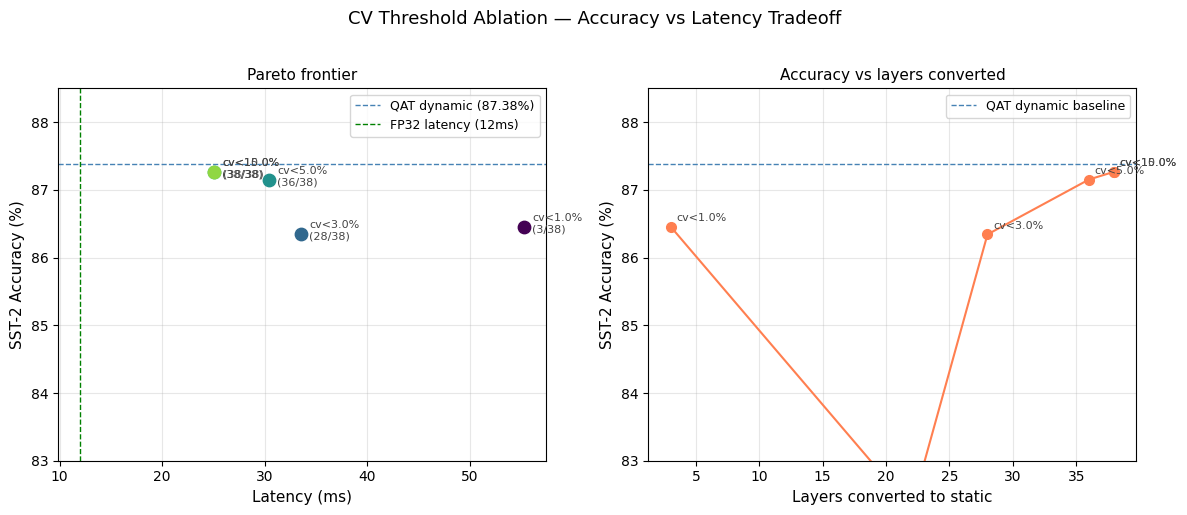

Saved to results/figures/


In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json

with open(f'{SAVE_DIR}/profiles/threshold_ablation.json') as f:
    results = json.load(f)

thresholds = [r['threshold'] for r in results]
accuracies = [r['accuracy']  for r in results]
latencies  = [r['latency']   for r in results]
converted  = [r['converted'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('CV Threshold Ablation — Accuracy vs Latency Tradeoff',
             fontsize=13, fontweight='normal', y=1.02)

# ── Left: Pareto curve (accuracy vs latency) ──
colors = plt.cm.viridis([i/len(results) for i in range(len(results))])
for i, r in enumerate(results):
    ax1.scatter(r['latency'], r['accuracy'],
                color=colors[i], s=80, zorder=5)
    ax1.annotate(f"cv<{r['threshold']}%\n({r['converted']}/38)",
                 (r['latency'], r['accuracy']),
                 textcoords='offset points', xytext=(6, -4),
                 fontsize=8, color='#444')

# reference lines
ax1.axhline(87.38, color='steelblue', linestyle='--',
            linewidth=1, label='QAT dynamic (87.38%)')
ax1.axvline(12.0,  color='green',     linestyle='--',
            linewidth=1, label='FP32 latency (12ms)')

ax1.set_xlabel('Latency (ms)', fontsize=11)
ax1.set_ylabel('SST-2 Accuracy (%)', fontsize=11)
ax1.set_title('Pareto frontier', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_ylim(83, 88.5)
ax1.grid(True, alpha=0.3)

# ── Right: layers converted vs accuracy ──
ax2.plot(converted, accuracies, 'o-', color='coral',
         linewidth=1.5, markersize=7)
for i, r in enumerate(results):
    ax2.annotate(f"cv<{r['threshold']}%",
                 (r['converted'], r['accuracy']),
                 textcoords='offset points', xytext=(4, 4),
                 fontsize=8, color='#444')

ax2.axhline(87.38, color='steelblue', linestyle='--',
            linewidth=1, label='QAT dynamic baseline')
ax2.set_xlabel('Layers converted to static', fontsize=11)
ax2.set_ylabel('SST-2 Accuracy (%)', fontsize=11)
ax2.set_title('Accuracy vs layers converted', fontsize=11)
ax2.legend(fontsize=9)
ax2.set_ylim(83, 88.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/figures/fig4_threshold_ablation.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(f'{SAVE_DIR}/figures/fig4_threshold_ablation.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved to results/figures/")